# **Rice Leaf Disease Classifier**


## **Import Modules**

In [1]:
import os
import sys
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import matplotlib.cm as cm

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import model_from_json

from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import confusion_matrix

print("Python:", sys.version.splitlines()[0])
print("TF version:", tf.__version__)
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
print("Numpy:", np.__version__)


Python: 3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]
TF version: 2.20.0
Num GPUs Available: 0
Numpy: 2.2.6


In [2]:
import sys, os
import tensorflow as tf
import numpy as np

print("Python:", sys.version.splitlines()[0])
print("TF version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))
print("Numpy:", np.__version__)

img_dir = "Rice Leaf Disease Images"
print("img_dir exists:", os.path.isdir(img_dir))
if os.path.isdir(img_dir):
  print("subfolders:", os.listdir(img_dir))

reqs = ["cv2","keras","livelossplot","wandb","py7zr"]
for r in reqs:
  try:
    __import__(r)
    print(f"{r}: OK")
  except Exception as e:
    print(f"{r}")

for var in ["rice_classifiers","corn_classifiers","x_test_augmented","y_test_augmented"]:
  print(var, "in globals:", var in globals())


Python: 3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]
TF version: 2.20.0
GPUs: []
Numpy: 2.2.6
img_dir exists: True
subfolders: ['.DS_Store', 'Bacterialblight', 'Blast', 'Brownspot', 'Tungro']
cv2: OK
keras: OK
livelossplot
wandb
py7zr
rice_classifiers in globals: False
corn_classifiers in globals: False
x_test_augmented in globals: False
y_test_augmented in globals: False


## **Improve Reproducibility**

In [3]:
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
random.seed(hash("setting random seeds") % 2**32 - 1)
np.random.seed(hash("improves reproducibility") % 2**32 - 1)
tf.random.set_seed(hash("by removing stochasticity")% 2**32 -1)

**GPU utilization**

In [4]:
from tensorflow.python.client import device_lib
device_lib.list_local_devices()

[name: "/device:CPU:0"
 device_type: "CPU"
 memory_limit: 268435456
 locality {
 }
 incarnation: 8373812797471919124
 xla_global_id: -1]

In [5]:
# device = tf.test.gpu_device_name()
# if device != '/device:GPU:0':
#   raise SystemError('GPU device not found!')

# print(f'Found GPU at: {device}')

## **Setup wanb environment**

In [6]:
#   pip install wandb
#   import wandb
#   wandb.login()


## **Data Inspection**

In [7]:
from pathlib import Path
img_dir = Path("Rice Leaf Disease Images")
if not img_dir.exists():
    raise FileNotFoundError(f"Data folder not found at {img_dir.resolve()}. Please put the dataset in this path.")

rows = []
for cls in sorted([p.name for p in img_dir.iterdir() if p.is_dir()]):
    for img_path in img_dir.joinpath(cls).glob('*'):
        try:
            arr = plt.imread(str(img_path))
            shape = arr.shape
        except Exception:
            shape = ()
        rows.append({"Image": str(img_path), "Label": cls, "Shape": shape})

img_df = pd.DataFrame(rows)
print(f"Found {len(img_df)} images across {img_df['Label'].nunique()} classes")
if len(img_df) > 0:
    display(img_df.head())


Found 5932 images across 4 classes


,Image,Label,Shape
0,Rice Leaf Disease Images\Bacterialblight\BACTE...,Bacterialblight,"(300, 300, 3)"
1,Rice Leaf Disease Images\Bacterialblight\BACTE...,Bacterialblight,"(300, 300, 3)"
2,Rice Leaf Disease Images\Bacterialblight\BACTE...,Bacterialblight,"(300, 300, 3)"
3,Rice Leaf Disease Images\Bacterialblight\BACTE...,Bacterialblight,"(300, 300, 3)"
4,Rice Leaf Disease Images\Bacterialblight\BACTE...,Bacterialblight,"(300, 300, 3)"


In [8]:
import os
img_dir_absolute = os.path.abspath("Rice Leaf Disease Images")
print(f"Image directory absolute path: {img_dir_absolute}")
print(f"Directory exists: {os.path.isdir(img_dir_absolute)}")
if os.path.isdir(img_dir_absolute):
    subfolders = os.listdir(img_dir_absolute)
    print(f"Subfolders: {subfolders}")
    for subfolder in subfolders:
        subfolder_path = os.path.join(img_dir_absolute, subfolder)
        if os.path.isdir(subfolder_path):
            file_count = len(os.listdir(subfolder_path))
            print(f"  - {subfolder}: {file_count} files")


Image directory absolute path: d:\DoAn\testmodel\Rice Leaf Disease Classifier\Rice Leaf Disease Images
Directory exists: True
Subfolders: ['.DS_Store', 'Bacterialblight', 'Blast', 'Brownspot', 'Tungro']
  - Bacterialblight: 1584 files
  - Blast: 1440 files
  - Brownspot: 1600 files
  - Tungro: 1308 files


Rice leaf samples categories

In [9]:
classifiers_list = os.listdir(img_dir)

#### **Rice Leaf Samples**

In [10]:
rice_classifiers = ['Bacterialblight', 'Blast', 'Brownspot', 'Tungro']
print(f'Total Rice classes {len(rice_classifiers)}, Rice disease categories in the dataset\n{rice_classifiers}')

Total Rice classes 4, Rice disease categories in the dataset
['Bacterialblight', 'Blast', 'Brownspot', 'Tungro']


**Define Rice Classifiers dictionary**

In [11]:
id_list = [i for i in range(len(rice_classifiers))]

rice_dict =  dict(zip(rice_classifiers, id_list))

print(f'Rice classifiers dictionary\n{rice_dict}')

Rice classifiers dictionary
{'Bacterialblight': 0, 'Blast': 1, 'Brownspot': 2, 'Tungro': 3}


Function for image to array conversion using keras  

In [12]:
def convert_img_to_array(image_path):
  try:
    img = plt.imread(image_path)
    if img is not None:
      return img_to_array(img)
    else:
      return np.array([])
  
  except Exception as e:
    print(f'Error {e}')
    return None

**Defining function for creating image array
 and labels list from the folder**

In [13]:
from pathlib import Path

DATA_DIR = Path("Rice Leaf Disease Images")
assert DATA_DIR.exists(), f"Data directory not found: {DATA_DIR.resolve()}"

IMAGE_SIZE = (128, 128)
BATCH_SIZE = 5
SEED = 123

train_ds = image_dataset_from_directory(
    str(DATA_DIR),
    validation_split=0.10,
    subset="training",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int'
)

val_test_ds = image_dataset_from_directory(
    str(DATA_DIR),
    validation_split=0.10,
    subset="validation",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int'
)

val_batches = tf.data.experimental.cardinality(val_test_ds).numpy()
val_ds = val_test_ds.take(val_batches // 2)

val_test_ds = image_dataset_from_directory(
    str(DATA_DIR),
    validation_split=0.10,
    subset="validation",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int'
)

test_ds = val_test_ds.skip(val_batches // 2)

class_names = train_ds.class_names
num_classes = len(class_names)
print('Classes:', class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)


Found 5932 files belonging to 4 classes.
Using 5339 files for training.
Found 5932 files belonging to 4 classes.
Using 593 files for validation.
Found 5932 files belonging to 4 classes.
Using 593 files for validation.
Classes: ['Bacterialblight', 'Blast', 'Brownspot', 'Tungro']


#### **Fetching images path for 4 classes for mendley rice dataset**

In [14]:
train_count = sum(1 for _ in train_ds)
val_count = sum(1 for _ in val_ds)
test_count = sum(1 for _ in test_ds)

print(f"Train batches: {train_count}, Validation batches: {val_count}, Test batches: {test_count}")
print(f"Batch size: {BATCH_SIZE}, Image size: {IMAGE_SIZE}, Num classes: {num_classes}")


Train batches: 1068, Validation batches: 59, Test batches: 60
Batch size: 5, Image size: (128, 128), Num classes: 4


In [15]:
print(f'Null check\n{img_df.isna().sum()}')

Null check
Image    0
Label    0
Shape    0
dtype: int64


#### **Target Analysis**




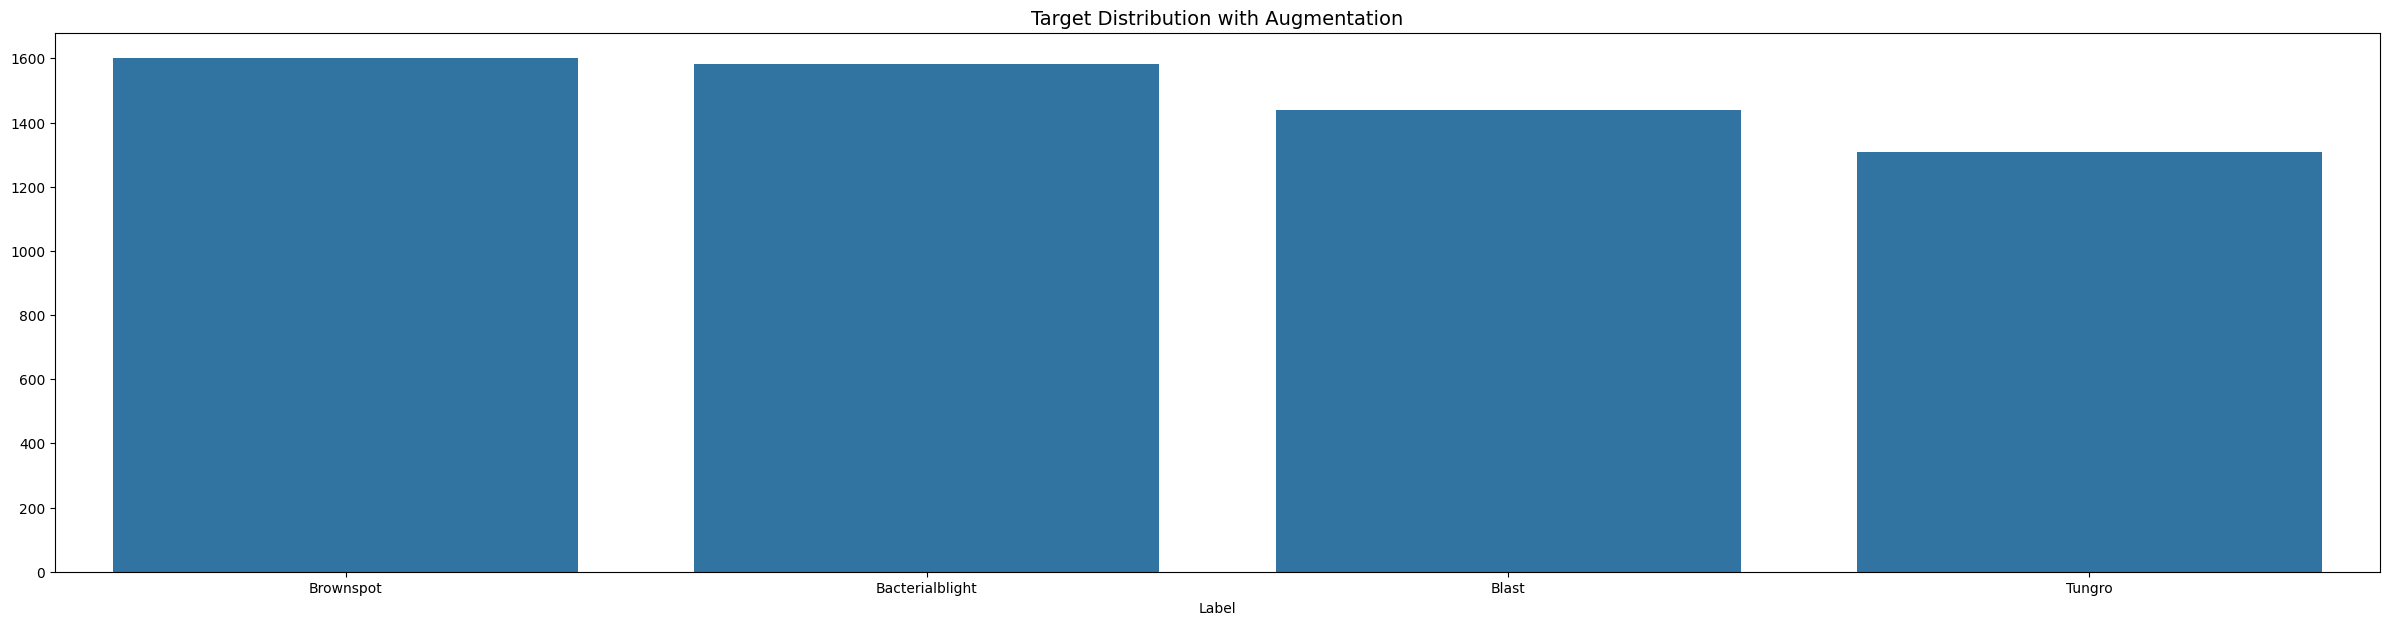

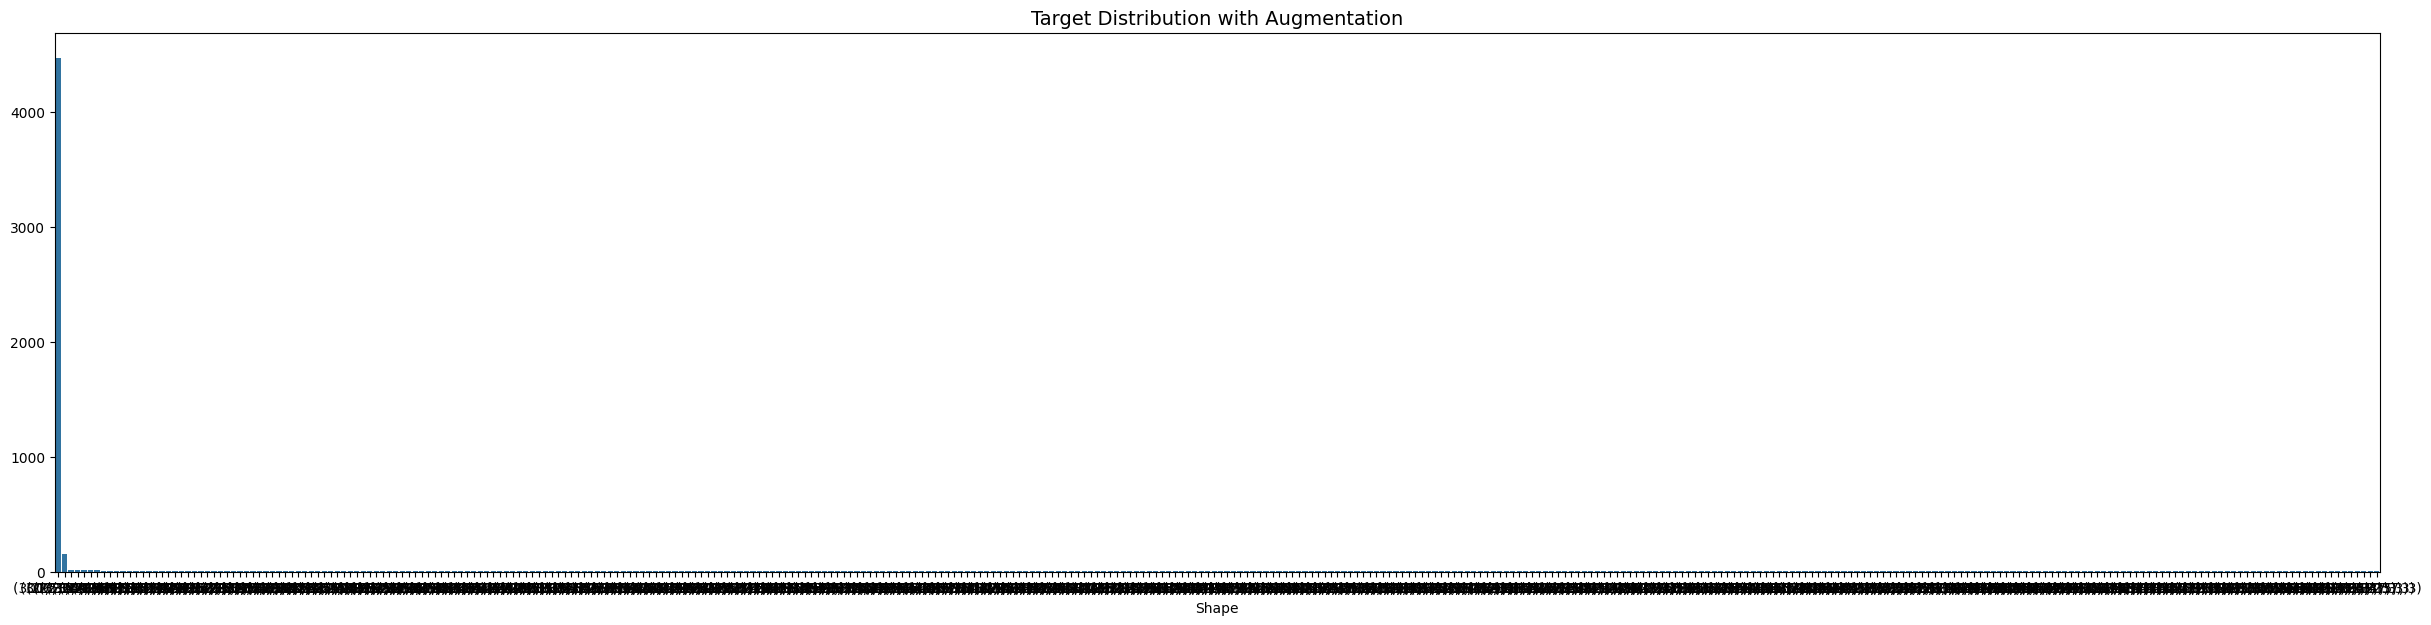

In [16]:
shape_counts = img_df['Shape'].value_counts()

def distribution(counts_series_augmented):
    fig = plt.figure(figsize=(30,7))
    sns.barplot(
        x = counts_series_augmented.index.astype(str),
        y = counts_series_augmented.values
    )
    plt.title('Target Distribution with Augmentation', fontsize=14)
    plt.show()

target_counts = img_df['Label'].value_counts()
distribution(target_counts)
distribution(shape_counts)


* We can see that data is a bit imbalanced
* We can see the images are of different shapes, thus we need to convert them in a common standard shaped

#### **Augmented Image Shapes EDA**

Image shape comparison between different categories 

Shape          Label          
(300, 300, 3)  Brownspot          1552
               Bacterialblight    1476
               Blast              1440
(300, 300, 4)  Bacterialblight     108
               Brownspot            48
                                  ... 
(597, 399, 3)  Tungro                2
(598, 399, 3)  Tungro                2
(599, 400, 3)  Tungro                2
(210, 280, 3)  Tungro                2
(209, 278, 3)  Tungro                2
Name: count, Length: 361, dtype: int64



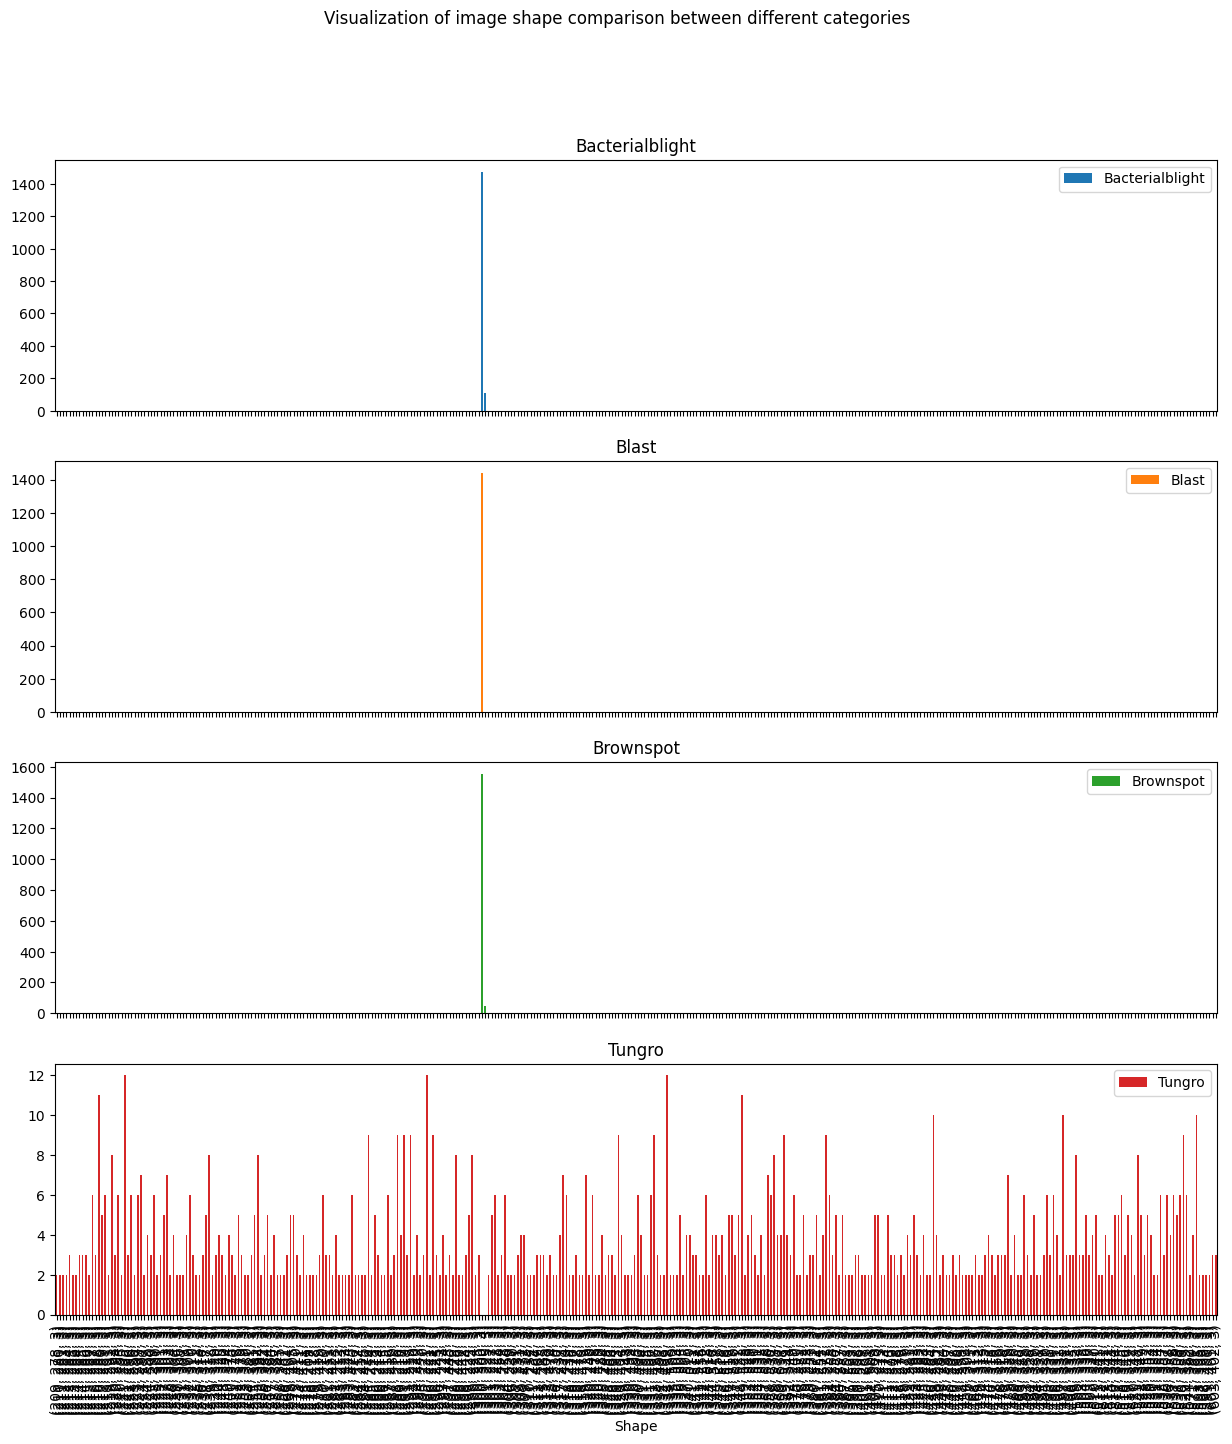

In [17]:
level_shape_df = img_df[['Shape', 'Label']].value_counts()
print(f'Image shape comparison between different categories \n\n{level_shape_df}\n')

level_shape_df.unstack(level = 1).plot(kind = 'bar', subplots = True, figsize = (15,15), 
                                       title = 'Visualization of image shape comparison between different categories')
plt.show()

## **Data Preparation**

#### **Experiment on 4 channel to 3 channel image conversion**

Function to rescale images

In [18]:
def img_rescale(img_path):
  img = cv2.imread(img_path, cv2.IMREAD_COLOR)
  if len(img.shape)>2 and img.shape[2]==4:
    img = cv2.cvtColor(img, cv2.COLOR_BGRA2BGR)
  img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
  img = img.astype(np.float32)

  img -= img.min()
  img /= (img.max() - img.min()) 

  return img

Find image name having 4 channels

In [19]:
sample_img_path = [img_df['Image'][a] for a,i in enumerate(img_df['Shape']) if i[2]==4][0]
print(f'Sample image shape(verify) having the alpha channel- {plt.imread(sample_img_path).shape}')

Sample image shape(verify) having the alpha channel- (300, 300, 4)


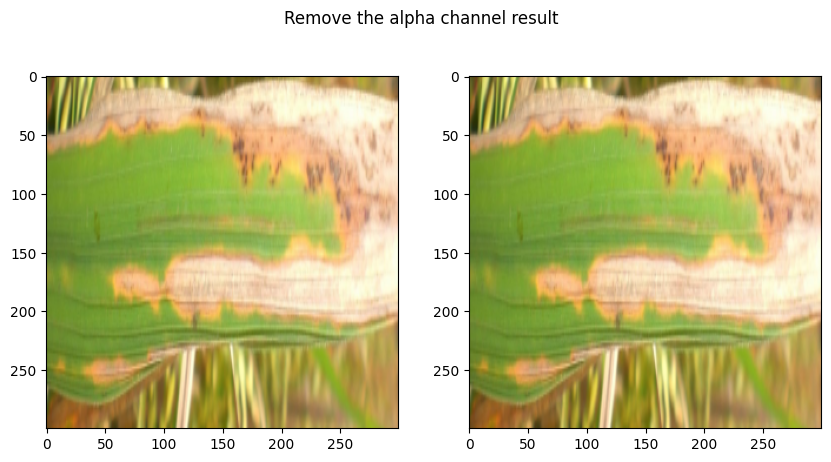

Image dtype before, after removal float32, float32
Image shape before, after removal (300, 300, 4), (300, 300, 3)


In [20]:
fig = plt.figure(figsize=(10,5))
fig.suptitle('Remove the alpha channel result')

img = plt.imread(sample_img_path)
fig.add_subplot(121)
plt.imshow(img)

img_rgb = img_rescale(sample_img_path)
fig.add_subplot(122)
plt.imshow(img_rgb)

plt.show()

print(f'Image dtype before, after removal {img.dtype}, {img_rgb.dtype}')
print(f'Image shape before, after removal {img.shape}, {img_rgb.shape}')

#### **Train-Validation-Test Split**

We are taking train, valid, test ratio as - [0.90:0.05:0.05]

In [21]:
val_ratio = 0.10
test_ratio = 0.5

img_ids = img_df.loc[:,'Image']

label_ids = img_df.loc[:,'Label']

**Defining train, validation dataframe**

In [22]:
train_df = pd.DataFrame(columns=['Image','Label'])
valid_main_df = pd.DataFrame(columns=['Image','Label'])
valid_df = pd.DataFrame(columns=['Image','Label'])
test_df = pd.DataFrame(columns=['Image','Label'])

**Defining Train, Valid, Test split**

Train-Valid_main split

In [23]:
train_df['Image'], valid_main_df['Image'], train_df['Label'], valid_main_df['Label'] = train_test_split(img_ids, label_ids,
                                                                                                        test_size = val_ratio,
                                                                                                        random_state = 28,
                                                                                                        stratify = label_ids,
                                                                                                        shuffle = True
                                                                                                        )

#print(f'Train dataframe shape {train_df.shape}')
#print(f'Validation dataframe shape {valid_main_df.shape}')

In [24]:
valid_df['Image'], test_df['Image'], valid_df['Label'], test_df['Label'] = train_test_split(valid_main_df.loc[:,'Image'], valid_main_df.loc[:,'Label'],
                                                                                                        test_size = test_ratio,
                                                                                                        random_state = 28,
                                                                                                        stratify = valid_main_df.loc[:,'Label'],
                                                                                                        shuffle = True
                                                                                                        )

print(f'Train dataframe shape {train_df.shape}')
print(f'Train dataframe shape {valid_df.shape}')
print(f'Validation dataframe shape {test_df.shape}')

Train dataframe shape (5338, 2)
Train dataframe shape (297, 2)
Validation dataframe shape (297, 2)


**Startification Check**

Defining visualization function for stratified train valid split

In [25]:
def distribution_vis_check(train, valid):
  '''
  Target distribution
  '''
  xdf = [train.index, valid.index]
  ydf = [train.values, valid.values]
  label = ['Train Distribution', 'Validation Distribution']
  fig = plt.figure(figsize=(20,5))
  for i in range(len(xdf)):
    fig.add_subplot(1, len(xdf), i+1)
    sns.barplot(x = xdf[i], y = ydf[i])
    plt.xlabel(label[i], fontsize = 16)

**Stratification result**

In [26]:
print('Startification result-')
print('Train set -\n{}'.format(train_df['Label'].value_counts()))
print('Validation set -\n{}'.format(valid_df['Label'].value_counts()))

Startification result-
Train set -
Label
Brownspot          1440
Bacterialblight    1425
Blast              1296
Tungro             1177
Name: count, dtype: int64
Validation set -
Label
Bacterialblight    80
Brownspot          80
Blast              72
Tungro             65
Name: count, dtype: int64


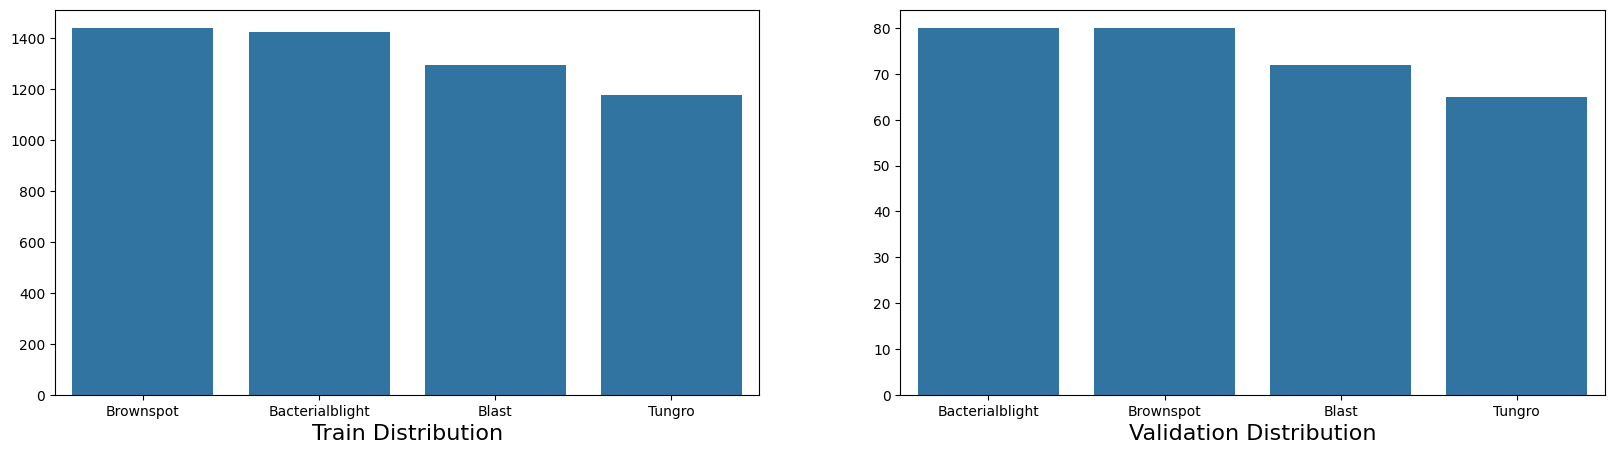

In [27]:
distribution_vis_check(train_df['Label'].value_counts(), valid_df['Label'].value_counts())

**Define the function to pre-process the image to keep the image pixel range within 0 to 1 range**

In [28]:
def pre_process(img):
  if len(img.shape)>2 and img.shape[2]==4:
    img = cv2.cvtColor(img, cv2.COLOR_BGRA2BGR)
  img -= img.min()
  img /= (img.max() - img.min()) 

  return img

**Define train, valid, test generator**

In [29]:
batch_size = 8
class_mode = 'sparse'
target_size = (256,256)
interpolation = 'bicubic'
columns = ['Image', 'Label']

In [30]:
from tensorflow.keras import layers

normalization_layer = layers.Rescaling(1./255)

data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.08),
], name='data_augmentation')

train_ds = train_ds.map(lambda x, y: (data_augmentation(normalization_layer(x), training=True), y), num_parallel_calls=AUTOTUNE)
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=AUTOTUNE)
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=AUTOTUNE)

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

print('Data augmentation and preprocessing ready')


Data augmentation and preprocessing ready


In [31]:
try:
    print('Train dataset element_spec:', train_ds.element_spec)
    print('Val dataset element_spec:', val_ds.element_spec)
    print('Test dataset element_spec:', test_ds.element_spec)
except NameError as e:
    print('Datasets not defined yet:', e)


Train dataset element_spec: (TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))
Val dataset element_spec: (TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))
Test dataset element_spec: (TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))


In [32]:
class _DummyGenerator:
    def __init__(self, batches, batch_size, class_indices, image_shape=(256,256,3), dtype=np.float32):
        self.batches = int(batches)
        self.batch_size = int(batch_size)
        self.class_indices = class_indices
        self.image_shape = image_shape
        self.dtype = dtype
        self.samples = self.batches * self.batch_size
        self.classes = np.zeros(self.samples, dtype=np.int32)
    def __len__(self):
        return self.batches
    def __getitem__(self, idx):
        raise RuntimeError("Legacy generator indexing is not supported in this notebook. Use the tf.data datasets: train_ds/val_ds/test_ds or helper functions.")

# create shims using the computed batch counts from the tf.data pipeline
train_generator = _DummyGenerator(train_count, BATCH_SIZE, rice_dict)
valid_generator = _DummyGenerator(val_count, BATCH_SIZE, rice_dict)
test_generator = _DummyGenerator(test_count, BATCH_SIZE, rice_dict)

print('Legacy generator shims created: train_generator, valid_generator, test_generator')


Legacy generator shims created: train_generator, valid_generator, test_generator


In [33]:
print(f"Number of training batches: {train_count}")
print(f"Number of validation batches: {val_count}")
print(f"Number of test batches: {test_count}")
print(f"Total: {train_count + val_count + test_count} batches")


Number of training batches: 1068
Number of validation batches: 59
Number of test batches: 60
Total: 1187 batches


**Visualize the generated images using keras imagedatagenerator**

In [34]:
def img_label_samples_from_dataset(dataset, class_count=None):
    """Return one sample image per class from a tf.data.Dataset.
    dataset: tf.data.Dataset yielding (images, labels)
    class_count: number of classes to sample (defaults to num_classes)
    """
    if class_count is None:
        class_count = num_classes
    samples = {i: None for i in range(class_count)}

    for x_batch, y_batch in dataset.unbatch().as_numpy_iterator():
        if isinstance(y_batch, (np.ndarray, list)) and np.ndim(y_batch) == 0:
            label = int(y_batch)
            img = x_batch
        else:
            try:
                label = int(y_batch)
                img = x_batch
            except Exception:
                continue

        if samples[label] is None:
            samples[label] = img

        if all(v is not None for v in samples.values()):
            break

    img_list = [samples[i] for i in range(class_count)]
    labels = list(range(class_count))
    return img_list, labels


In [35]:
img_list, labels = img_label_samples_from_dataset(train_ds, class_count=num_classes)

print("Number of samples in img_list:", len(img_list))

if len(img_list) > 0:
    print(f"Image data max: {img_list[0].max():.4f}, min: {img_list[0].min():.4f}")
    print(f"Image shape: {img_list[0].shape}, dtype: {img_list[0].dtype}")
else:
    print("img_list is empty!")


Number of samples in img_list: 4
Image data max: 0.9975, min: 0.0240
Image shape: (128, 128, 3), dtype: float32


**Visualize the generated images using keras imagedatagenerator**

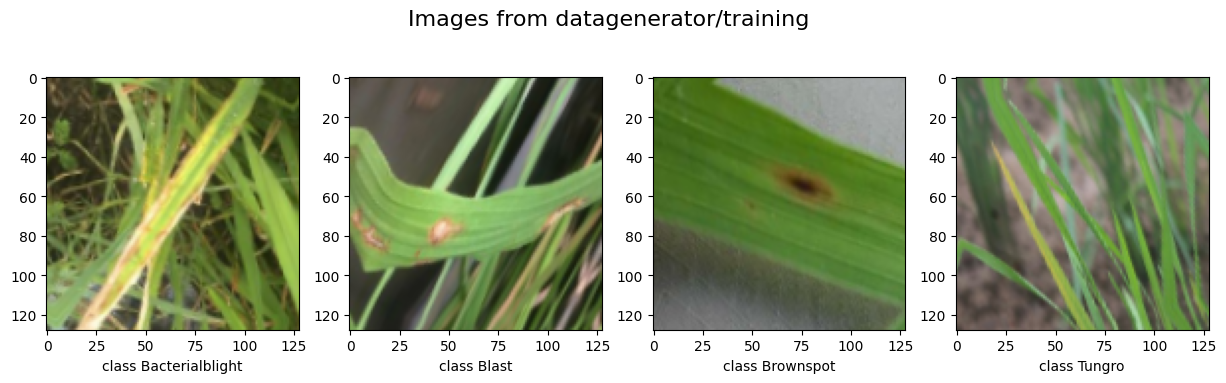

In [36]:
fig = plt.figure(figsize=(15,4))
fig.suptitle('Images from datagenerator/training', fontsize = 16)
fig.tight_layout()

for i, (img, label) in enumerate(zip(img_list, labels)):
  fig.add_subplot(1,len(img_list), i+1)
  plt.imshow(img)
  plt.xlabel(f'class {rice_classifiers[label]}')

plt.show()

## **CNN Model Building**

In [37]:
input_shape = (256,256,3)
num_classes = len(rice_classifiers)
print(f'Model input_shape {input_shape}')
print(f'Number of output class {num_classes}')

Model input_shape (256, 256, 3)
Number of output class 4


In [38]:
def make_model(input_shape=(128, 128, 3), num_classes=4, base_trainable=False, use_imagenet=True):
    weights_arg = 'imagenet' if use_imagenet else None
    try:
        base_model = tf.keras.applications.MobileNetV2(input_shape=input_shape,
                                                       include_top=False,
                                                       weights=weights_arg)
    except Exception as e:
        print('Warning: could not load imagenet weights (network/SSL issue?). Falling back to random init. Error:', e)
        base_model = tf.keras.applications.MobileNetV2(input_shape=input_shape,
                                                       include_top=False,
                                                       weights=None)

    base_model.trainable = base_trainable

    inputs = keras.Input(shape=input_shape)
    x = layers.Rescaling(2.0, offset=-1.0)(inputs)  

    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name='mobilenetv2_finetune')
    return model

input_shape = (128, 128, 3)
model = make_model(input_shape=input_shape, num_classes=num_classes, base_trainable=False, use_imagenet=True)
model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "mobilenetv2_finetune"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,263,108 (8.63 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## **Model Training**

#### Defining Hyperparameters and Metadata 

In [39]:
learning_rate = 0.001 
epochs = 5
batch_size = 8
loss_fn = 'sparse_categorical_crossentropy'

#### **Configuring wandb to initialize and log training**

In [40]:
keras.backend.clear_session()

optimizer = Adam(learning_rate)
model.compile(optimizer=optimizer, loss = loss_fn, metrics = ['acc'])

**Storing initial weights of model for resetting weights**

In [41]:
model.save_weights('model_initial.weights.h5')

In [42]:
# model.save('model_full.h5')  
print("Initial model structure saved. Ready for training.")

Initial model structure saved. Ready for training.


Defining callbacks

Reduce learning rate on plateu helps to rescue the training curve when it gets stuck in the plateu. [Reeference](https://keras.io/api/callbacks/reduce_lr_on_plateau/)

In [43]:
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
import os

MODEL_DIR = Path('Model')
MODEL_DIR.mkdir(parents=True, exist_ok=True)

best_model_path = MODEL_DIR / 'best_model.keras'

mc = ModelCheckpoint(filepath=str(best_model_path),
                     monitor='val_accuracy',
                     save_best_only=True,
                     save_weights_only=False,
                     mode='max',
                     verbose=1)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=4, verbose=1)

early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1)

callbacks_list = [mc, reduce_lr, early_stop]

print('Callbacks ready. Best model will be saved to', best_model_path)


Callbacks ready. Best model will be saved to Model\best_model.keras


#### **Training the Model with original dataset**

Model training and visualizing with livelossplot

In [44]:
keras.backend.clear_session()

Reset weights

In [45]:
steps = val_count
print('Validation steps (batches):', steps)


Validation steps (batches): 59


In [46]:
print("Validation batches:", val_count)
print("Nominal batch size:", BATCH_SIZE)
print("Validation batches * batch_size (approx):", val_count * BATCH_SIZE)


Validation batches: 59
Nominal batch size: 5
Validation batches * batch_size (approx): 295


In [47]:
try:
    if os.path.exists('model_initial.weights.h5'):
        model.load_weights('model_initial.weights.h5')
        print("Loaded initial weights")
    else:
        print("No initial weights file found; continuing with current model weights")

    loss_initial, acc_initial = model.evaluate(val_ds, verbose=1)
    print(f"\n✓ Initial Model Baseline:")
    print(f"  Loss: {loss_initial:.4f}")
    print(f"  Accuracy: {acc_initial:.4f}")
except Exception as e:
    print('Evaluation error (initial):', e)


Loaded initial weights
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - acc: 0.2373 - loss: 1.6977

✓ Initial Model Baseline:
  Loss: 1.6977
  Accuracy: 0.2373


In [48]:
import glob

try:
    if isinstance(best_model_path, (str, Path)) and Path(best_model_path).exists():
        print('Loading full model from', best_model_path)
        best_model = keras.models.load_model(str(best_model_path))
        loss_trained, acc_trained = best_model.evaluate(val_ds)
        print(f"\n✓ Trained Model Performance (from checkpoint):")
        print(f"  Loss: {loss_trained:.4f}")
        print(f"  Accuracy: {acc_trained:.4f}")
    else:
        checkpoint_files = glob.glob('Model/*.keras') + glob.glob('Model/*.h5')
        if checkpoint_files:
            ck = sorted(checkpoint_files)[-1]
            print('Loading model from', ck)
            best_model = keras.models.load_model(ck)
            loss_trained, acc_trained = best_model.evaluate(val_ds)
            print(f"\n✓ Trained Model Performance (from {ck}):")
            print(f"  Loss: {loss_trained:.4f}")
            print(f"  Accuracy: {acc_trained:.4f}")
        else:
            print('❌ No checkpoint files found in Model/. Make sure training saved the model with ModelCheckpoint.')
except Exception as e:
    print('Error while loading/evaluating best model:', e)


Loading full model from Model\best_model.keras
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.3051 - loss: 1.3808

✓ Trained Model Performance (from checkpoint):
  Loss: 1.3808
  Accuracy: 0.3051


##### Learning rate optimization

**From the curve upto at 1e-03 the loss is least and smooth, after that it rises and diturbance starts, thus, optimal_lr = 1e-03 taken.**

In [49]:
train_steps = train_count
print('Train steps (batches):', train_steps)


Train steps (batches): 1068


In [50]:
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model.fit(
    train_ds,
    epochs=epochs,
    validation_data=val_ds,
    callbacks=callbacks_list,
    verbose=1
)

print('Training finished. Best model saved by ModelCheckpoint if validation improved.')


Epoch 1/5
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7600 - loss: 0.6029
Epoch 1: val_accuracy improved from None to 0.95932, saving model to Model\best_model.keras
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 35s 30ms/step - accuracy: 0.8496 - loss: 0.3786 - val_accuracy: 0.9593 - val_loss: 0.1393 - learning_rate: 0.0010
Epoch 2/5
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9369 - loss: 0.1794
Epoch 2: val_accuracy improved from 0.95932 to 0.96949, saving model to Model\best_model.keras
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 32s 30ms/step - accuracy: 0.9374 - loss: 0.1706 - val_accuracy: 0.9695 - val_loss: 0.0928 - learning_rate: 0.0010
Epoch 3/5
1066/1068 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9376 - loss: 0.1682
Epoch 3: val_accuracy improved from 0.96949 to 0.97966, saving model to Model\best_model.keras
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 31s 29ms/step - accuracy: 0.9410 - loss: 0.1593 - val_accuracy: 0.9797 - val_loss: 0.0761 - learning_rate: 0.0010
Epoch 4/5
1067/1068

##### Visualize learning rate scheduler output in log scale

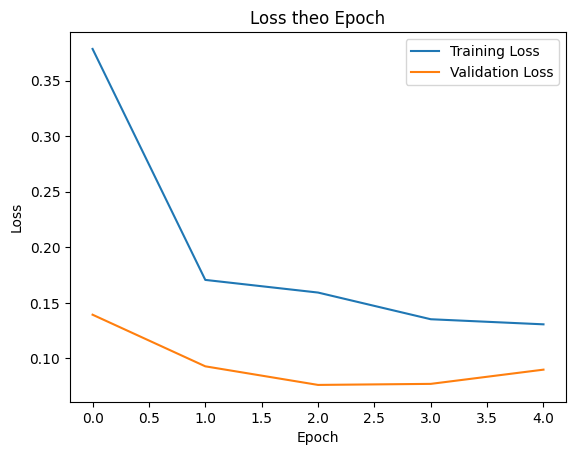

In [51]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history.get('val_loss', []), label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss theo Epoch')
plt.legend()
plt.show()


In [52]:
model_file = 'Corn_augmented_model.h5'
model.save(model_file)
print(f'Model saved to {model_file}')


Model saved to Corn_augmented_model.h5
